This is based on the Skeleton_cluster.ipynb Notebook
check:

https://bitbucket.imp.ac.at/users/ulises.rey/repos/skeleton/browse

I want to batch do what the Skeleton_cluster.ipynb does.
import packages
define functions.

*part I:

    go over every ome.tiff file in root folder
    
    generate HeadTail coordinates
    
*part II:

    go over every ome.tiff file in root folder
    
    skeletonize and generate output

In [1]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os
import shutil
from natsort import natsorted
import sys
import re

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

In [2]:
#define functions

#define shortest_path function
def shortest_path(start,end,binary):
    costs=np.where(binary,1,1000)
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=False)
    return path,cost,costs

## Part I: deeplabcut
The model is generated in the deeplabcut_projects/DLC.ipynb notebook.

Here we only analyze videos with the previously trained network.

In [1]:
#deeplabcut part
import os
import pandas as pd
import numpy as np
os.environ["DLClight"]="True"
import deeplabcut

DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


## FOR LOOP ON THE CODE BELOW:

In [ ]:
#modify this
path ='/groups/zimmer/Ulises/code/deeplabcut_projects/'
exp= 'HeadTailChemotaxis-Ulises-2020-06-25_copy'
path_config_file = path+exp+'/config.yaml'
path_config_file

#don't edit these:
VideoType = 'avi' 
videofile_path = [path+exp+'/videos/'] #Enter the list of videos or folder to analyze.
videofile_path

#ANALYZE VIDEOS
deeplabcut.analyze_videos(path_config_file,videofile_path, videotype=VideoType)

#CREATE LABELED VIDEO
deeplabcut.create_labeled_video(path_config_file,videofile_path, videotype=VideoType)

## Part II: Skeletonize

Prior to these I should see how omega turns are handled.

In [3]:
#define default output path
output_path='/groups/zimmer/Ulises/code/skeleton_outputs/'
try: os.mkdir(output_path)
except: print('Output Directory already exists')

Output Directory already exists


In [4]:
#load path
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/20200609/2020-06-09_15-53-33_chemotaxis_worm5-channel-0-/'
file='2020-06-09_15-53-33_chemotaxis_worm5-channel-0-_MMStack_1.ome.tif'
#file='2020-06-05_18-01-23_worm4-channel-0-_MMStack.ome.tif'

#path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/20200605/2020-06-05_18-01-23_worm4-channel-0-/'
#file='2020-06-05_18-01-23_worm4-channel-0-_MMStack.ome.tif'
file_path=path+file

retval, mats=cv2.imreadmulti(file_path)
video=np.asarray(mats)
video.shape

(11381, 610, 608)

In [5]:
video.shape

(11381, 610, 608)

Text(0.5, 1.0, '(inv) background')

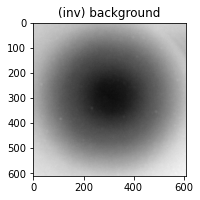

In [6]:
#background image, obtained from fiji
#develop further to get a z-projection in here, or use a bg image generated in fiji
bg_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/20200609/2020-06-09_16-15-10_chemotaxis_worm5_bg-channel-0-/'
bg_file='MED_2020-06-09_16-15-10_chemotaxis_worm5_bg-channel-0-_MMStack.ome-1.tif'
bg_file_path=bg_path+bg_file
bg_img=cv2.imread(bg_file_path,0)
bg_img=cv2.bitwise_not(bg_img)
#show background
plt.subplot(1,2,1)
plt.imshow(bg_img,cmap='gray')
plt.title('(inv) background')

In [7]:
#load HDF5 file with coordinates
h5_path='/groups/zimmer/Ulises/code/deeplabcut_projects/HeadTailChemotaxis-Ulises-2020-06-25_copy/videos_done/'

#dataname='2020-06-09_15-53-33_chemotaxis_worm5-channel-0-_MMStack_1.ome_150fps_JPGDLC_resnet50_HeadTailChemotaxisJun25shuffle1_27000.h5'
#dataname='2020-06-09_15-53-33_chemotaxis_worm5-channel-0-_MMStack_1.ome_150fps_JPGDLC_resnet50_HeadTailChemotaxisJun25shuffle1_20000.h5'
dataname='2020-06-09_15-53-33_chemotaxis_worm5-channel-0-_MMStack_1.ome_150fps_JPGDLC_resnet50_HeadTailChemotaxisJun25shuffle1_20000.h5'

#worm4
#h5_path='/groups/zimmer/Ulises/code/deeplabcut_projects/HeadTailChemotaxis-Ulises-2020-06-25_copy/videos_done/'
#dataname='2020-06-05_18-01-23_worm4-channel-0-_MMStack.omeDLC_resnet50_HeadTailChemotaxisJun25shuffle1_20000.h5'

#loading output of DLC
df = pd.read_hdf(h5_path+dataname)
df.head(5)
scorer=df.columns.get_level_values(0)[0]
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values

In [14]:
#to plot head and tail
#n_frames=500
#new_video=video[0:n_frames].copy()
new_video=video.copy()

for k, img in enumerate(new_video):
    cv2.circle(img, (int(head_x[k]), int(head_y[k])), 20, (255,0,0), 2)
    cv2.circle(img, (int(tail_x[k]), int(tail_y[k])), 5, (255,0,0), 2)
    
#file variable contains the file name from few cells above
tiff.imsave(output_path+'head_tail_annotation'+file+'.tiff',new_video, bigsize=True)

In [7]:
#it seems what I was doing with floodfill is pretty much BS.
#I should use findContours, connectedComponentWithStats and Moments.

n_frames=6000
new_video=video[0:n_frames].copy()

Actual code:

In [8]:
#Actual code

new_video=video.copy()
# n_frames=100
# new_video=video[0:n_frames].copy()
#os.remove('second_der.csv')


#declare variables:
#second derivative
sec_der=[]
knots=100

all_x_new=np.zeros((new_video.shape[0],knots))
all_y_new=np.zeros((new_video.shape[0],knots))
all_der=np.zeros((new_video.shape[0],knots))
all_K=np.zeros((new_video.shape[0],knots))

#for every frame (img) k
for k, img in enumerate(new_video):
    
    img[:]=cv2.bitwise_not(img)
    
    #substrack background and store it in sub
    img[:]=cv2.subtract(img,bg_img)
    
    #median Blur
    img[:] = cv2.medianBlur(img,5)
    #apply threshold
    ret, new_img = cv2.threshold(img,11,255,cv2.THRESH_BINARY)
    #find contours
    _,contours, hierarchy = cv2.findContours(new_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    #list areas of contours, find MAX, draw contours from MAX area
    areas=[]
    for i in range(0, len(contours)):
        areas.append(cv2.contourArea(contours[i]))
    
    worm_contour=np.where(areas==np.asarray(areas).max())
    worm_contour=np.asarray(worm_contour)
    
    img_contours = np.zeros(img.shape)
    img[:]=cv2.drawContours(img_contours,contours, worm_contour, 255, -1)
    
    #centerline part:
    #run skeletonize
    img_copy=img/255
    skeleton = skeletonize(img_copy)
    
    #Scikit graph approach

    ### give start (y1,x1) and end (y2,x2) and the binary maze image as input
    #shortest path

    start_point =  (int(head_y[k]), int(head_x[k]))#(286, 124)#
    end_point = (int(tail_y[k]), int(tail_x[k]))#(332,480)#

    path, cost, costs=shortest_path(start_point, end_point, skeleton)
    
    #somehow the coordinates are the other way around
    y, x = zip(*path)
    
    pts=np.asarray(path, dtype=np.int)

    ####
    #s is the smoothing condition should have around the size of points/2 (keep it low)
    #k is the degree of freedom for the polynom it fits, 5 is good
    #splprep calculates automatically the number of knots. One can see how many in tck.shape[1].
    #everytime splprep is run the number by differ
    tck, u = splprep(pts.T, u=None, s=pts.shape[0]/2, per=0, k=5) 
    u_new = np.linspace(u.min(), u.max(), knots)#1000)

    x_new, y_new = splev(u_new, tck, der=0)

    #this returns x'(s), y'(s)
    x_der, y_der = splev(u_new, tck, der=1)
    #to have y'(x):
    der=y_der/x_der

    #this returns x''(s), y''(s)
    x_der2, y_der2 = splev(u_new, tck, der=2)
    #to have y''(x), also called K for Curvature:
    #we need the following equation:
    #ref in: https://en.wikipedia.org/wiki/Curvature#In_terms_of_a_general_parametrization (1st equation)
    K=(x_der*y_der2-y_der*x_der2)/np.sqrt(x_der**2+y_der**2)**3
    ####
    
    #np.savetxt("second_der.csv", y_der2, delimiter=",")

    for point in path:
        y, x = zip(point)
        img[y,x]=1

    
    #append in a variable
    #all_pts[k]=pts
    all_x_new[k]=x_new
    all_y_new[k]=y_new
    all_der[k]=der
    all_K[k]=K
    
    #append_list_as_row('first_der.csv', y_der)
    #append_list_as_row('second_der2.csv', K)
    
    img[:]=img

   
tiff.imsave(output_path+'binary_output_.tiff',new_video, bigtiff=True)
np.savetxt(output_path+'second_der_np_new.csv', all_K, delimiter=",")
np.savetxt(output_path+'x_new_np.csv', all_x_new, delimiter=",")
np.savetxt(output_path+'y_new_np.csv', all_y_new, delimiter=",")

In [13]:
#IT OUTPUTS THE SAME AS ABOVE BUT WITH COLORS

# n_frames=100
# new_video=video[0:n_frames].copy()
#os.remove('second_der.csv')

#choose video or new_video to plot angles on top of the raw data or binary-centerline
newest_video=new_video.copy()

new_c_video=np.full((newest_video.shape[0],newest_video.shape[1],newest_video.shape[2],3), 0, dtype='uint8')
new_c_video[:,:,:,0]=newest_video
new_c_video[:,:,:,1]=newest_video
new_c_video[:,:,:,2]=newest_video
print(new_c_video.shape)
print(all_K.shape)
Kmax=all_K.max()

#tiff.imsave('input_tiff.tiff',new_video)

# #for every frame (img) k
for k, img in enumerate(new_c_video):
#     k
#     plt.imshow(img)
#     plt.show()
#     print(img.shape)
    #plt.imsave('rgb_im.tiff',img)
    
    #for every knot
    for i, K_value in enumerate(all_K[k]):
        #print('K value in '+str(i)+ ' is: '+str(K_value))
        #print(int(K_value))
        y, x = int(all_y_new[k][i]),int(all_x_new[k][i])
        #normalize k value to 255, important to do it
        K_value=K_value/0.03*255
        if K_value>0:
            #img[x][y][0]=K_value/Kmax*2550
            #print('before norm'+K_value)
            #print('after'+K_value/0.05*255)            
            cv2.circle(img,(y,x), 3, (K_value,0,0),-1)
        if K_value<0:
            #print('before norm'+K_value)
            #print('after'+-K_value/0.05*255)  
            #img[x][y][2]=-K_value/Kmax*2550
            cv2.circle(img,(y,x), 3, (0,0,-K_value),-1)
    
tiff.imsave(output_path+'bw_colored_output5_2.tiff',new_c_video)
#tiff.imsave('new_img.tiff',new_img)

(11381, 610, 608, 3)
(11381, 100)


In [93]:
##Plottting Derivative
for frame, k_v in enumerate(all_K):
    x_new=all_x_new[frame]
    y_new=all_y_new[frame]
    der=all_der[frame]
    K=all_K[frame]

    x_cord=np.arange(0,100,1)

    plt.figure(figsize=(20,10))
    r,c=2,2
    # ax1=plt.subplot(r,c,1)
    # plt.plot(x_cord, y_new, 'bo')
    # plt.title('Worm')

    #first der
    ax3=plt.subplot(r,c,1)
    #plt.plot(x_cord,der)
    plt.scatter(x_cord, der, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    ax3.set_ylim(-5, 5)

    plt.axhline(y=0, xmin=0, xmax=1)
    #ax3.set_ylim(-2, 2)
    #ax3.set_xlim(400, 450)
    plt.title('First Derivative')

    ax5=plt.subplot(r,c,2)
    #plt.plot(x_new, der2, 'o')
    plt.scatter(x_cord, K, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#, vmin=-5000, vmax=5000)#y_der2, marker='.', cmap='bwr')
    ax5.set_ylim(-0.1, 0.1)

    plt.axhline(y=0, xmin=0, xmax=1)
    plt.title('Second Derivative')

    #worm first der
    ax2=plt.subplot(r,c,3)
    sc=plt.scatter(x_new, y_new, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    #plt.colorbar(sc)
    plt.title('Color coded worm from First Derivative')



    ax4=plt.subplot(r,c,4)
    sc=plt.scatter(x_new, y_new, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#y_der2, marker='.', cmap='bwr')
    #plt.colorbar(sc)
    plt.title('Color coded worm from Second Derivative')
    plt.savefig('derivatives/'+str(frame)+'.tiff')
    plt.close()

KeyboardInterrupt: 

<Figure size 1440x720 with 0 Axes>

In [17]:
tck[1].shape

NameError: name 'tck' is not defined

In [112]:
path='/groups/zimmer/Ulises/code/skeleton/derivatives/'

figure=np.full((0,720,1440,3), 0, dtype='uint8')
figure.shape
for filename in natsorted(os.listdir(path))[0:1000]:
    #print(filename)
    fig=cv2.imread(path+filename)
    fig.shape=(1,720,1440,3)
    #print(fig.shape)
    figure=np.concatenate([figure,fig],0)
tiff.imsave('figure2.tiff',figure, bigsize=True)

In [3]:
#PCA part
#after: https://towardsdatascience.com/pca-using-python-scikit-learn-e653f8989e60
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




In [4]:
df=pd.read_csv('second_der_np_new.csv', header=None)
df.shape

(11381, 100)

In [5]:
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(df)
principalComponents.shape
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2','PC3','PC4','PC5'])

In [6]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(df)
principalComponents.shape
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2'])

In [87]:
principalComponents.shape

(11381, 2)

In [67]:
principalComponents

array([[ 0.13001558,  0.14385494, -0.01657826, -0.14478786, -0.07722827],
       [ 0.02205997,  0.13937472, -0.02147388, -0.14596268, -0.06938011],
       [ 0.08562406,  0.13406714, -0.0169649 , -0.14717834, -0.08142163],
       ...,
       [-0.07750406, -0.0549897 ,  0.12915941,  0.08327126,  0.05888336],
       [-0.10277167, -0.06739281,  0.1260803 ,  0.08117016,  0.05731669],
       [-0.09814602, -0.05341151,  0.12565186,  0.08441473,  0.05585401]])

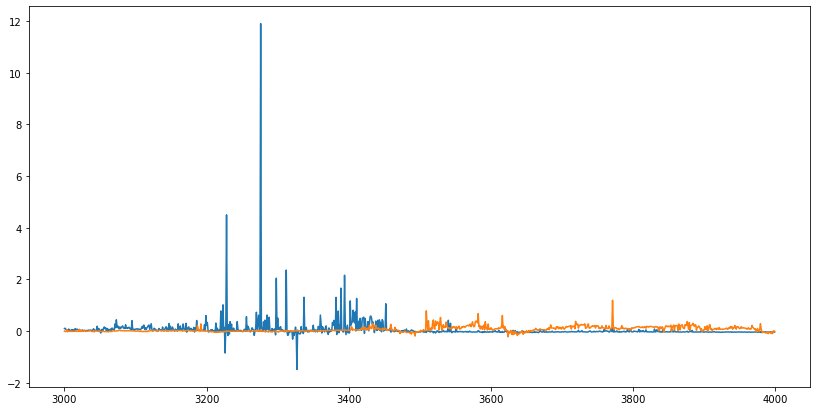

In [13]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [49]:
principalComponents[0][:]

array([0.13001558, 0.14385494])

In [45]:
principalComponents[:][:][1]

array([0.02205997, 0.13937472])

KeyError: 0

In [104]:
np.arange(0,100)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

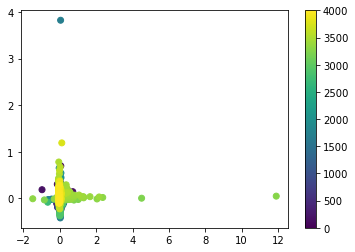

In [8]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

(-0.2, 0.2)

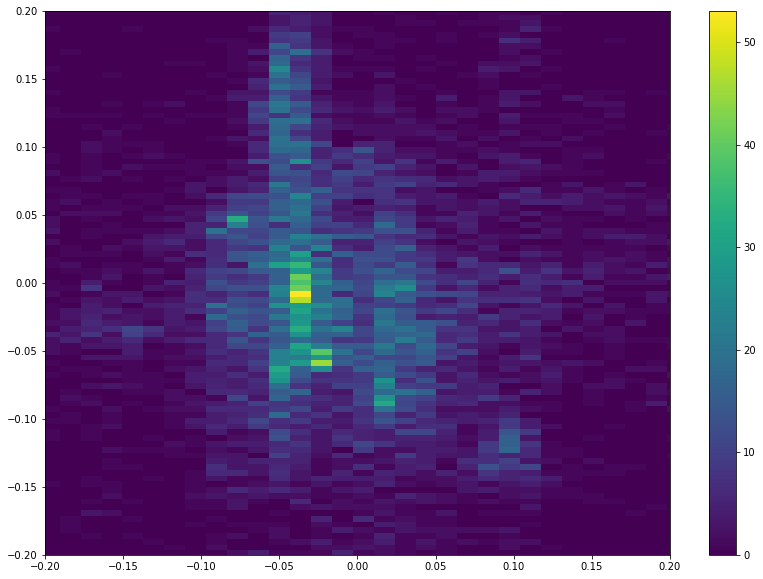

In [10]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

(-0.5, 0.5)

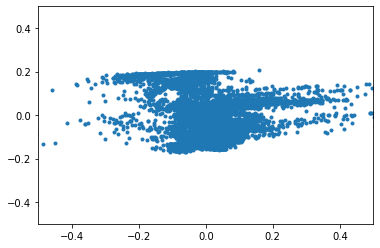

In [72]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

(-0.5, 0.5)

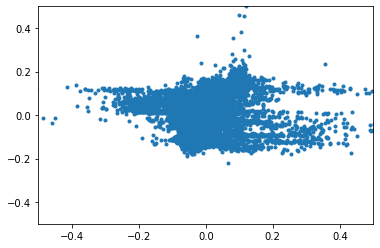

In [73]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)